In [1]:
class value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"value(data ={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, value) else value(other)
        out =value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad+=1.0*out.grad
            other.grad += 1.0 * out.grad
        

        out._backward= _backward
            
        
        return out  
    
    def __mul__(self, other):
        other = other if isinstance(other, value) else value(other)
        out = value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = value(self.data ** other, (self,), f'**{other}')
        
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    def __radd__(self, other):
        return self + other
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
    def tanh(self):
        import math
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        import math
        x = self.data
        out = value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad += 1.0
        for node in reversed(topo):
            node._backward()




In [2]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this op node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [3]:
#input x1, x2
x1 = value(2.0, label ='x1')
x2 = value(0.0, label ='x2')
#weights w1 and w2
w1 = value(-3.0, label ='w1')
w2 = value(1.0, label ='w2')
#bias 
b = value(6.881373570195432, label ='b')
# math +b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()




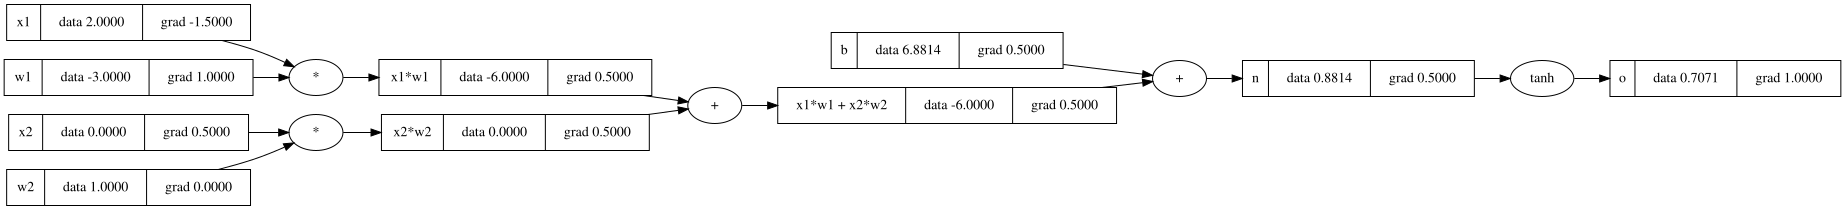

In [4]:

draw_dot(o)

In [5]:
import torch

In [6]:
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(0.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True) 
w2 = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(6.881373570195432, requires_grad=True)
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data.item())
o.backward()

print('-------')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())


0.7071067094802856
-------
x2 0.5000001192092896
w2 0.0
x1 -1.5000003576278687
w1 1.000000238418579


In [7]:
class neuron:
    def __init__(self, nin):
        import random
        self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = value(random.uniform(-1,1))
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
class layer:
    def __init__(self, nin, nout):
        self.neurons = [neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out [0] if len(out) == 1 else out
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        

class mlp:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [16]:
x = [2.0 , 3.0, -1.0]
n = mlp(3, [4,4,1])
n(x)

value(data =-0.8372339390684158)

In [17]:
xs = [
[2.0,3.0,-1.0],
[3.0,-1.0,0.5],
[0.5,1.0,1.0],
[1.0,1.0,-1.0],
]
ys = [1.0, -1.0, -1.0, -1.0] # desired targets

In [37]:
for k in range(20):
  #forward pass  
  ypred = [n(x) for x in xs]
  loss = sum(([(yout - ygt)**2 for ygt , yout in zip(ys, ypred)]))

  #backward pass
  for p in n.parameters():
        p.grad = 0.0
  loss.backward()

  #update 
  for p in n.parameters():
      p.data += -0.1 * p.grad
  print(k, loss.data)


0 0.0024197966982330513
1 0.002404266647886044
2 0.0023889244693612224
3 0.002373766844703435
4 0.0023587905327506894
5 0.0023439923669409854
6 0.002329369253193425
7 0.002314918167860909
8 0.0023006361557513953
9 0.002286520328215163
10 0.0022725678612956603
11 0.0022587759939412776
12 0.002245142026275802
13 0.0022316633179254807
14 0.002218337286400235
15 0.0022051614055273853
16 0.0021921332039354273
17 0.002179250263586707
18 0.0021665102183563334
19 0.002153910752656385


In [38]:
ypred

[value(data =0.9690572146354286),
 value(data =-0.9913159010538996),
 value(data =-0.9794105405677159),
 value(data =-0.9735970575064233)]